# COVID19 Worldwide Testing Data

Explore the worldwide COVID-19 testing dataset using pandas.

## Load the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("tested_worldwide.csv")
df

,Date,Country_Region,Province_State,positive,active,hospitalized,hospitalizedCurr,recovered,death,total_tested,daily_tested,daily_positive
0,2020-01-16,Iceland,All States,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-17,Iceland,All States,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2020-01-18,Iceland,All States,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
3,2020-01-20,South Korea,All States,1.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
4,2020-01-22,United States,All States,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
27636,2020-11-09,Australia,Queensland,NaN,8.0,NaN,8.0,1163.0,6.0,1265567.0,0.0,NaN
27637,2020-11-09,Australia,South Australia,NaN,19.0,NaN,0.0,492.0,4.0,572618.0,0.0,NaN
27638,2020-11-09,Australia,Tasmania,NaN,0.0,NaN,0.0,217.0,13.0,120292.0,0.0,NaN
27639,2020-11-09,Australia,Victoria,NaN,4.0,NaN,2.0,19522.0,819.0,3299302.0,0.0,NaN


## First Five Rows

In [2]:
df.head()

,Date,Country_Region,Province_State,positive,active,hospitalized,hospitalizedCurr,recovered,death,total_tested,daily_tested,daily_positive
0,2020-01-16,Iceland,All States,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-17,Iceland,All States,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2020-01-18,Iceland,All States,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
3,2020-01-20,South Korea,All States,1.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
4,2020-01-22,United States,All States,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN


## Number of Rows and Columns

In [3]:
df.shape

(27641, 12)

## Data Types

In [4]:
df.dtypes

Date                    str
Country_Region          str
Province_State          str
positive            float64
active              float64
hospitalized        float64
hospitalizedCurr    float64
recovered           float64
death               float64
total_tested        float64
daily_tested        float64
daily_positive      float64
dtype: object

## Missing Values

In [5]:
df.isna().sum()

Date                    0
Country_Region          0
Province_State          0
positive             4242
active               9833
hospitalized        19231
hospitalizedCurr    13080
recovered            9626
death                4010
total_tested          912
daily_tested         1174
daily_positive       4557
dtype: int64

## Unique Values

In [6]:
df.nunique()

Date                  297
Country_Region        147
Province_State         81
positive            14998
active               9554
hospitalized         4862
hospitalizedCurr     2904
recovered            9183
death                5641
total_tested        23610
daily_tested        13375
daily_positive       3440
dtype: int64

## Data Cleaning

Select the columns needed for the analysis and prepare them for aggregation.

## Select and Rename Columns

In [7]:
clean_df = df[["Country_Region", "positive", "total_tested"]].copy()

clean_df = clean_df.rename(columns={
    "Country_Region": "country",
    "positive": "positive_cases",
    "total_tested": "tests_conducted"
})

clean_df.head()

,country,positive_cases,tests_conducted
0,Iceland,3.0,NaN
1,Iceland,4.0,NaN
2,Iceland,7.0,NaN
3,South Korea,1.0,4.0
4,United States,0.0,0.0


## Convert Types and Remove Missing Values

In [8]:
clean_df["positive_cases"] = pd.to_numeric(
    clean_df["positive_cases"], errors="coerce"
)
clean_df["tests_conducted"] = pd.to_numeric(
    clean_df["tests_conducted"], errors="coerce"
)

clean_df = clean_df.dropna()
clean_df["country"] = clean_df["country"].astype("string")

clean_df.head()

,country,positive_cases,tests_conducted
3,South Korea,1.0,4.0
4,United States,0.0,0.0
5,United States,0.0,0.0
6,United States,0.0,0.0
7,United States,0.0,0.0


## Verify Missing Values

In [9]:
clean_df.isna().sum()

country            0
positive_cases     0
tests_conducted    0
dtype: int64

## Top 10 Countries by Positive Cases

In [10]:
positive_by_country = (
    clean_df.groupby("country", as_index=False)["positive_cases"]
    .sum()
    .sort_values("positive_cases", ascending=False)
)

top_10_positive = positive_by_country.head(10)
top_10_positive

,country,positive_cases
112,United States,1.837768e+09
48,Italy,6.419921e+07
17,Canada,5.096042e+07
7,Bangladesh,4.377194e+07
106,Turkey,1.655613e+07
26,Czechia,1.082225e+07
88,Russia,1.066327e+07
2,Armenia,7.225809e+06
21,Costa Rica,6.655702e+06
111,United Kingdom,4.924956e+06


## Top 10 Countries by Tests Conducted

In [11]:
tests_by_country = (
    clean_df.groupby("country", as_index=False)["tests_conducted"]
    .sum()
    .sort_values("tests_conducted", ascending=False)
)

top_10_tests = tests_by_country.head(10)
top_10_tests

,country,tests_conducted
112,United States,2.359218e+10
17,Canada,1.797987e+09
48,Italy,1.547472e+09
47,Israel,3.881970e+08
3,Australia,3.232333e+08
88,Russia,3.003005e+08
7,Bangladesh,2.331498e+08
106,Turkey,2.283259e+08
26,Czechia,1.800656e+08
39,Greece,1.421012e+08


## Top Three Countries by Positive-to-Test Ratio

In [12]:
comparison = positive_by_country.merge(
    tests_by_country,
    on="country",
    how="inner"
)

comparison = comparison[comparison["tests_conducted"] > 0]

comparison["positive_test_ratio"] = (
    comparison["positive_cases"] / comparison["tests_conducted"]
)

comparison = comparison.sort_values(
    "positive_test_ratio",
    ascending=False
)

top_3_ratio = comparison.head(3)
top_3_ratio

,country,positive_cases,tests_conducted,positive_test_ratio
106,Tanzania,509.0,652.0,0.780675
103,Burkina Faso,641.0,1333.0,0.480870
50,Ecuador,91850.0,284956.0,0.322330


## Visualizing the Results

The following charts show the top three positive-to-test ratios, the top ten countries by positive cases, and the top ten countries by tests conducted.

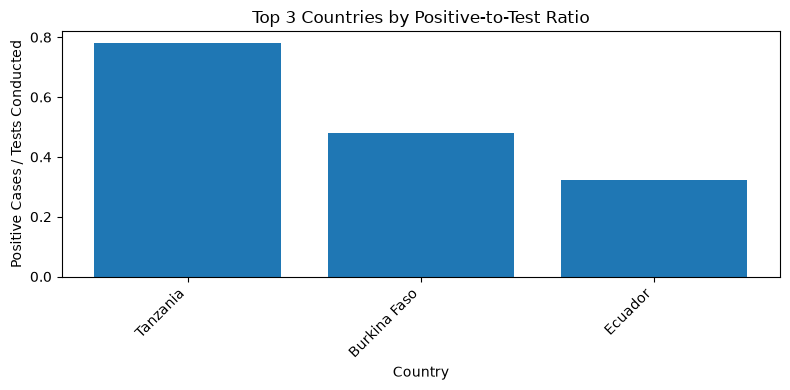

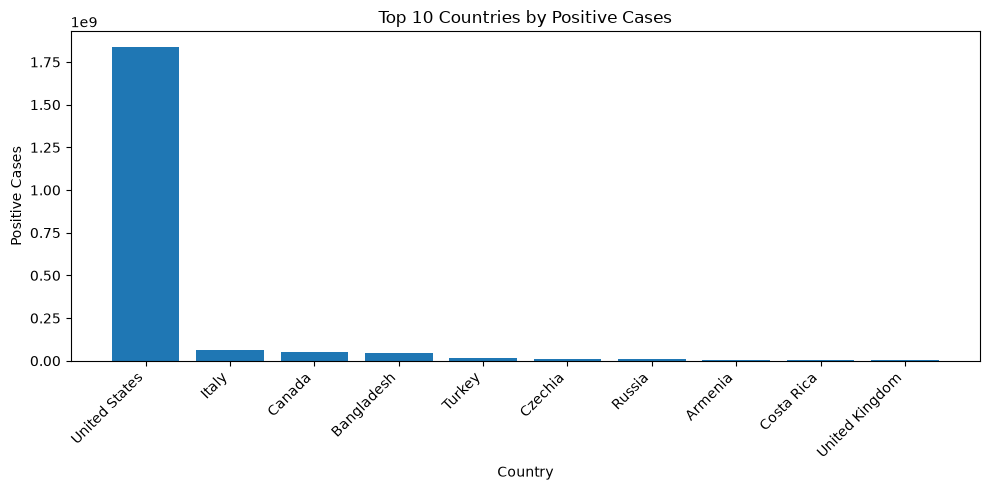

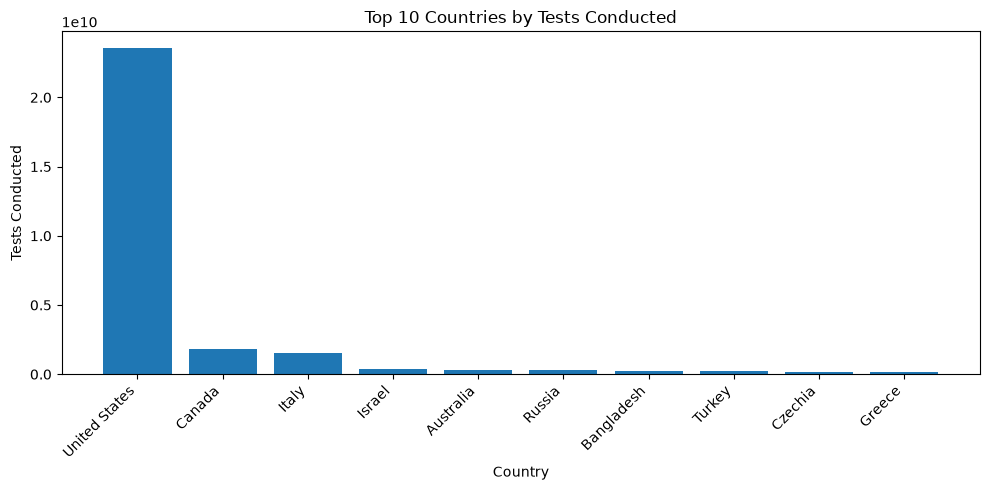

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(top_3_ratio["country"], top_3_ratio["positive_test_ratio"])
plt.title("Top 3 Countries by Positive-to-Test Ratio")
plt.xlabel("Country")
plt.ylabel("Positive Cases / Tests Conducted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(top_10_positive["country"], top_10_positive["positive_cases"])
plt.title("Top 10 Countries by Positive Cases")
plt.xlabel("Country")
plt.ylabel("Positive Cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(top_10_tests["country"], top_10_tests["tests_conducted"])
plt.title("Top 10 Countries by Tests Conducted")
plt.xlabel("Country")
plt.ylabel("Tests Conducted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Conclusion

- Which countries have the highest positive-to-test ratios?
- Which countries have the most positive cases and tests conducted?
- The dataset contains repeated dates and regional rows, so summing all records may double-count cumulative values.
- A stronger follow-up would use the latest cumulative record per country and compare results over time.